In [ ]:
!pip uninstall -y tensorflow tensorflow-cpu tensorflow-gpu \
                 tensorflow_compression tensorflow-compression-ops

In [ ]:
!pip install --upgrade "tensorflow==2.14.0"

In [ ]:
# restart

In [ ]:
!pip install "tensorflow-compression==2.14.1"

In [2]:
# restart

In [3]:
import tensorflow as tf, tensorflow_compression as tfc
import pkg_resources, inspect
print("TFC:", pkg_resources.get_distribution("tensorflow_compression").version)
print("TF :", tf.__version__)

2025-07-11 09:39:54.992444: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-11 09:39:54.993352: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-11 09:39:54.993431: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TFC: 2.14.1
TF : 2.14.0


In [4]:
#––– 1) Uyumlu tensorflow-compression kurulumu
!pip install -q --upgrade --no-deps tensorflow-compression==2.14.1

#––– 2) Modeller klasörünü yalnızca ilk kez klonla
import os, sys
if not os.path.isdir('/tfc'):
    !git clone --depth 1 https://github.com/tensorflow/compression /tfc

#––– 3) tfci.py’yi bulabilmesi için PYTHONPATH’e ekle
if '/tfc' not in sys.path:
    sys.path.insert(0, '/tfc')

#––– 4) Çalışma dizinini /tfc/models olarak ayarla
%cd /tfc/models

#––– 5) Kontrol: tfci başarıyla import ediliyor mu?
import tensorflow as tf, tensorflow_compression as tfc, tfci
print("TF :", tf.__version__)
print("TFC paketi yüklü ✓")
print("tfci modülü yüklendi ✓")

Cloning into '/tfc'...
remote: Enumerating objects: 318, done.
remote: Counting objects: 100% (318/318), done.
remote: Compressing objects: 100% (209/209), done.
remote: Total 318 (delta 129), reused 218 (delta 103), pack-reused 0 (from 0)
Receiving objects: 100% (318/318), 347.09 KiB | 8.46 MiB/s, done.
Resolving deltas: 100% (129/129), done.
/tfc/models
TF : 2.14.0
TFC paketi yüklü ✓
tfci modülü yüklendi ✓


In [5]:
import tensorflow as tf, tensorflow_compression as tfc
import pkg_resources, inspect
print("TFC:", pkg_resources.get_distribution("tensorflow_compression").version)
print("TF :", tf.__version__)

TFC: 2.14.1
TF : 2.14.0


In [6]:
import tensorflow as tf

if not tf.config.list_physical_devices('GPU'):
  print('WARNING: No GPU found. Might be slow!')
else:
  print('Found GPU.')

In [7]:
import os
from PIL import Image
import tensorflow as tf
import tfci   # artık bulunacak
import matplotlib.pyplot as plt

tf.get_logger().setLevel('WARN')



# Girdi ve çıktı klasörleri
FILES_DIR = '/kaggle/input/basit-model/deneme'  
OUT_DIR   = '/kaggle/working/out'
os.makedirs(OUT_DIR, exist_ok=True)

In [8]:
import collections

# Sıkıştırma sonucu meta bilgi tutmak için
FileInfo = collections.namedtuple('FileInfo', ['image','model','bpp'])

def get_bpp(img_size, num_bytes):
    w,h = img_size
    return num_bytes * 8 / (w*h)

def list_images(dir_path, exts={'.png','.jpg','.jpeg'}):
    return [f for f in os.listdir(dir_path)
            if os.path.splitext(f)[1].lower() in exts]


In [9]:
# 1–8 arası MSE ve MS-SSIM varyantları
mse_models    = [f"bmshj2018-factorized-mse-{i}"    for i in range(1,9)]
msssim_models = [f"bmshj2018-factorized-msssim-{i}" for i in range(1,9)]

all_models = mse_models + msssim_models

results = []

for model_name in all_models:
    print(f"\n=== Model: {model_name} ===")
    for fname in list_images(FILES_DIR):
        inp = os.path.join(FILES_DIR, fname)
        base, ext = os.path.splitext(fname)
        cmp = os.path.join(OUT_DIR, f"{base}_{model_name}.tfci")
        out = os.path.join(OUT_DIR, f"{base}_{model_name}.png")

        # Compress
        print(f"Compressing {fname} → {model_name}")
        tfci.compress(model_name, inp, cmp)

        # Byte size
        size_bytes = os.path.getsize(cmp)

        # Decompress
        print(f"Decompressing → {base}_{model_name}.png")
        tfci.decompress(cmp, out)

        # Hesapla
        img = Image.open(inp)
        bpp = get_bpp(img.size, size_bytes)
        results.append(FileInfo(base, model_name, bpp))



=== Model: bmshj2018-factorized-mse-1 ===
Compressing art.jpg → bmshj2018-factorized-mse-1
Decompressing → art_bmshj2018-factorized-mse-1.png

=== Model: bmshj2018-factorized-mse-2 ===
Compressing art.jpg → bmshj2018-factorized-mse-2
Decompressing → art_bmshj2018-factorized-mse-2.png

=== Model: bmshj2018-factorized-mse-3 ===
Compressing art.jpg → bmshj2018-factorized-mse-3
Decompressing → art_bmshj2018-factorized-mse-3.png

=== Model: bmshj2018-factorized-mse-4 ===
Compressing art.jpg → bmshj2018-factorized-mse-4
Decompressing → art_bmshj2018-factorized-mse-4.png

=== Model: bmshj2018-factorized-mse-5 ===
Compressing art.jpg → bmshj2018-factorized-mse-5
Decompressing → art_bmshj2018-factorized-mse-5.png

=== Model: bmshj2018-factorized-mse-6 ===
Compressing art.jpg → bmshj2018-factorized-mse-6
Decompressing → art_bmshj2018-factorized-mse-6.png

=== Model: bmshj2018-factorized-mse-7 ===
Compressing art.jpg → bmshj2018-factorized-mse-7
Decompressing → art_bmshj2018-factorized-mse-7.png

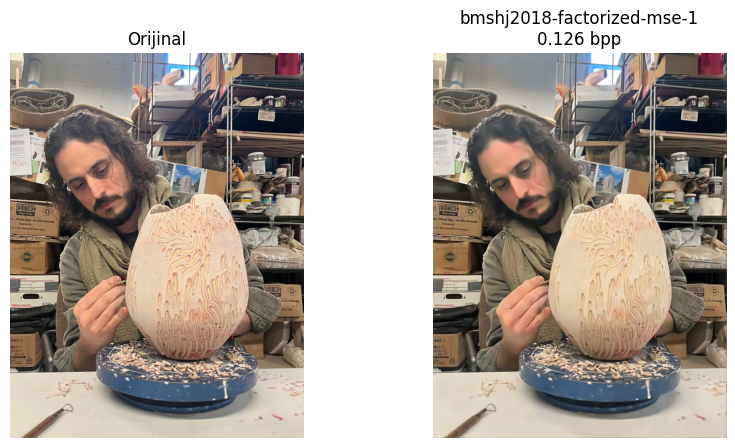

In [10]:
# İlk model ve ilk resim üzerinden örnek gösterelim
sample = results[0]
orig = Image.open(os.path.join(FILES_DIR, sample.image + ext))
rec  = Image.open(os.path.join(OUT_DIR,    f"{sample.image}_{sample.model}.png"))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Orijinal')
plt.axis('off')
plt.imshow(orig)

plt.subplot(1,2,2)
plt.title(f"{sample.model}\n{sample.bpp:.3f} bpp")
plt.axis('off')
plt.imshow(rec)
plt.show()


In [11]:
import pandas as pd

df = pd.DataFrame(results)
df.columns = ['Image','Model','Bits-per-pixel']
# Modele göre sıralı
df_sorted = df.sort_values(['Model','Image']).reset_index(drop=True)
df_sorted


,Image,Model,Bits-per-pixel
0,art,bmshj2018-factorized-mse-1,0.125993
1,art,bmshj2018-factorized-mse-2,0.200081
2,art,bmshj2018-factorized-mse-3,0.302444
3,art,bmshj2018-factorized-mse-4,0.443787
4,art,bmshj2018-factorized-mse-5,0.634714
5,art,bmshj2018-factorized-mse-6,0.894058
6,art,bmshj2018-factorized-mse-7,1.275871
7,art,bmshj2018-factorized-mse-8,1.786822
8,art,bmshj2018-factorized-msssim-1,0.093330
9,art,bmshj2018-factorized-msssim-2,0.157598


In [12]:
import shutil

# OUT_DIR içindeki tüm dosyaları tek bir ZIP dosyasına alıyoruz
zip_base = '/kaggle/working/all_results'   # .zip uzantısı otomatik eklenir
archive_path = shutil.make_archive(base_name=zip_base,
                                   format='zip',
                                   root_dir=OUT_DIR)

print(f"Arşiv oluşturuldu: {archive_path}")


Arşiv oluşturuldu: /kaggle/working/all_results.zip
